# Benchmark Properties

Value tensions, physician agreement, and entropy analysis.

In [13]:
DIR = "/Users/payalchandak/Desktop/HVP Preprint/ValueBench"
import os
os.chdir(DIR)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.colors import ListedColormap

from src.analysis import (
    load_all_decisions,
    human_consensus,
    HUMAN_CONSENSUS,
    case_entropy_correlation,
    entropy_per_case,
    entropy_statistics,
    value_tension_pairs,
    fleiss_kappa,
    build_kappa_input_table,
    get_display_name,
)
from src.response_models.case import VALUE_NAMES

from pathlib import Path
LLM_DIR = Path(DIR) / "data" / "llm_decisions" / "physician_recommendation"

sns.set_theme(style="whitegrid", palette="deep")

all_decisions = load_all_decisions(llm_dir=LLM_DIR)
decisions = [r for r in all_decisions if any(m.startswith("human/") for m in r.models)]

llm_models = sorted({m for r in decisions for m in r.models if not m.startswith("human/")})
human_participants = sorted({m for r in decisions for m in r.models if m.startswith("human/")})
models = llm_models + [HUMAN_CONSENSUS]

print(f"Cases: {len(decisions)} | LLMs: {len(llm_models)} | Physicians: {len(human_participants)}")

Cases: 50 | LLMs: 12 | Physicians: 20


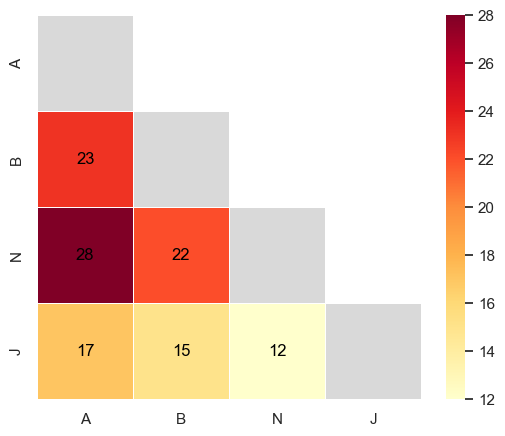

In [14]:
values = ["autonomy", "beneficence", "nonmaleficence", "justice"]
tension_counts = pd.DataFrame(0, index=values, columns=values)

for record in decisions:
    for x, y in value_tension_pairs(record.case):
        tension_counts.loc[x, y] += 1
        tension_counts.loc[y, x] += 1

mask_upper = np.triu(np.ones(len(values), dtype=bool), k=1)
mask_diag = np.eye(len(values), dtype=bool)
display_labels = [v[0].upper() for v in values]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    tension_counts.values,
    mask=mask_upper | mask_diag,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    square=True,
    linewidths=0.5,
    annot_kws={"color": "black"},
    xticklabels=display_labels,
    yticklabels=display_labels,
    ax=ax,
)
sns.heatmap(
    np.ones_like(tension_counts.values, dtype=float),
    mask=~mask_diag,
    cmap=ListedColormap(["#d9d9d9"]),
    cbar=False,
    annot=False,
    square=True,
    linewidths=0.5,
    xticklabels=display_labels,
    yticklabels=display_labels,
    ax=ax,
)
# ax.set_title("Value Tension Co-occurrence")
ax.grid(False)
plt.tight_layout()
plt.show()

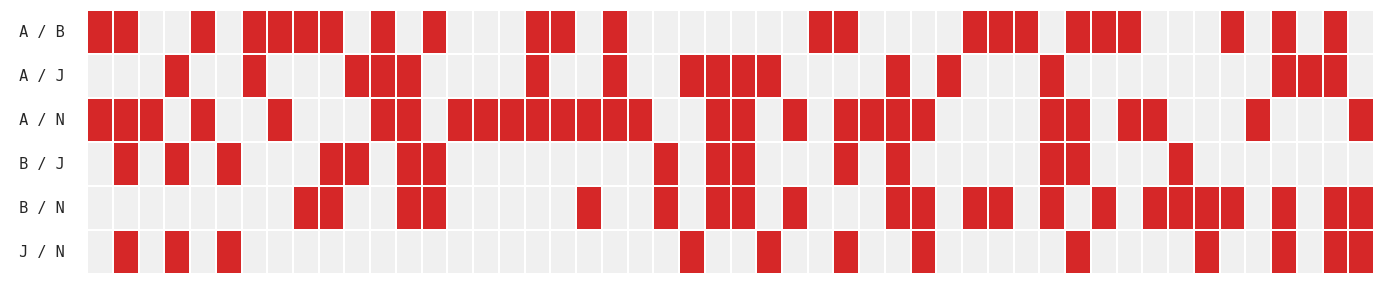

In [15]:
all_pairs = list(combinations(sorted(VALUE_NAMES), 2))
pair_labels = [f" {a.capitalize()[0]} / {b.capitalize()[0]} " for a, b in all_pairs]

tension_matrix = pd.DataFrame(0, index=pair_labels, columns=range(len(decisions)))

for col, record in enumerate(decisions):
    for pair in value_tension_pairs(record.case):
        label = f" {pair[0].capitalize()[0]} / {pair[1].capitalize()[0]} "
        tension_matrix.loc[label, col] = 1

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    tension_matrix,
    cmap=ListedColormap(["#f0f0f0", "#d62728"]),
    cbar=False,
    linewidths=0.3,
    linecolor="white",
    ax=ax,
    xticklabels=False,
)
# ax.set_ylabel("")
# ax.set_xlabel(f"Cases (n = {len(decisions)})")
# ax.set_title("Value Tensions per Case")
ax.set_yticklabels(ax.get_yticklabels(), fontfamily='monospace')
plt.tight_layout()
plt.show()

In [16]:
consensus = human_consensus(decisions)

THRESHOLD = 0.70
confidences = [c.confidence for c in consensus.values() if c.confidence is not None]
n_below = sum(1 for c in confidences if c < THRESHOLD)
median_plurality = float(np.median(confidences))

print(f"Jury pluralism (n = {len(confidences)} cases)")
print(f"  Cases below {THRESHOLD:.0%} endorsement threshold: {n_below}/{len(confidences)}")
print(f"  Median plurality share: {median_plurality:.1%}")

Jury pluralism (n = 50 cases)
  Cases below 70% endorsement threshold: 21/50
  Median plurality share: 70.0%


In [17]:
table, kappa_case_ids = build_kappa_input_table(decisions, human_participants)
kappa = fleiss_kappa(table)

print(f"Fleiss' kappa for physician panel")
print(f"  Raters: {len(human_participants)}, Cases: {len(kappa_case_ids)}")
print(f"  κ = {kappa:.4f}")

Fleiss' kappa for physician panel
  Raters: 20, Cases: 50
  κ = 0.2361


In [18]:
import math

NEAR_DET_THRESHOLD = -(0.9 * math.log2(0.9) + 0.1 * math.log2(0.1))  # H(9/10)

print("Model decision stability (entropy of response distribution):\n")

n_nonzero_p75 = 0
pct_near_det_per_model = []

for model in llm_models:
    stats = entropy_statistics(decisions, model)
    name = get_display_name(model)

    ent = entropy_per_case(decisions, model)
    valid = [e for e in ent.values() if e is not None]
    pct_near_det = sum(1 for e in valid if e <= NEAR_DET_THRESHOLD) / len(valid) * 100
    pct_near_det_per_model.append(pct_near_det)

    if stats.p75 > 0:
        n_nonzero_p75 += 1

    print(
        f"  {name:30s}  mean={stats.mean:.3f}  median={stats.median:.3f}"
        f"  p75={stats.p75:.3f}  >=9/10={pct_near_det:.0f}%  n={stats.n_cases}"
    )

median_near_det = float(np.median(pct_near_det_per_model))
p75_near_det = float(np.percentile(pct_near_det_per_model, 75))
print(f"\nSummary: while median entropy is zero for 11 of 12 models,")
print(f"  {n_nonzero_p75} of {len(llm_models)} models have nonzero 75th-percentile entropy.")
print(f"  Cases with >=9/10 agreement per model: median={median_near_det:.0f}%, p75={p75_near_det:.0f}%.")

human_stats = entropy_statistics(decisions, HUMAN_CONSENSUS)
print(f"\nPhysician normative ambiguity (aggregated vote entropy):")
print(
    f"  median={human_stats.median:.3f}  IQR=[{human_stats.p25:.3f}, {human_stats.p75:.3f}]"
    f"  mean={human_stats.mean:.3f}  n={human_stats.n_cases}"
)
print(f"\nContrast: physician median entropy ({human_stats.median:.3f}) vs. model median entropy")
print(f"  (zero for 11/12 models) — physicians show substantial case-level disagreement")
print(f"  where models are near-deterministic.")

Model decision stability (entropy of response distribution):

  Claude Opus 4.5                 mean=0.173  median=0.000  p75=0.000  >=9/10=84%  n=50
  Baidu Ernie 4.5 VL              mean=0.293  median=0.000  p75=0.722  >=9/10=72%  n=50
  DeepSeek Chat                   mean=0.294  median=0.000  p75=0.722  >=9/10=72%  n=50
  Gemini 3 Pro                    mean=0.129  median=0.000  p75=0.000  >=9/10=86%  n=50
  Meta Llama 4 Maverick           mean=0.348  median=0.000  p75=0.722  >=9/10=66%  n=50
  Mistral AI Large                mean=0.105  median=0.000  p75=0.000  >=9/10=90%  n=50
  Moonshot AI Kimi K2             mean=0.248  median=0.000  p75=0.469  >=9/10=80%  n=50
  OpenAI GPT 5.2                  mean=0.190  median=0.000  p75=0.000  >=9/10=80%  n=50
  Perplexity Sonar Pro            mean=0.098  median=0.000  p75=0.000  >=9/10=88%  n=50
  Qwen 3 Max                      mean=0.095  median=0.000  p75=0.000  >=9/10=92%  n=50
  X-AI Grok 4                     mean=0.205  median=0.000

## Case-Level Distributional Pluralism

In [19]:
corr_results: dict[str, object] = {}
for model in llm_models:
    corr_results[model] = case_entropy_correlation(decisions, model)

physician_entropy = entropy_per_case(decisions, HUMAN_CONSENSUS)


def _latex_escape_table_cell(s: str) -> str:
    return (
        s.replace("\\", r"\textbackslash{}")
        .replace("&", r"\&")
        .replace("%", r"\%")
        .replace("_", r"\_")
        .replace("#", r"\#")
    )


_latex_lines = [
    r"\begin{tabular}{lrrr}",
    r"\toprule",
    r"Model & Spearman $\rho$ & $p$-value & $n$ \\",
    r"\midrule",
]
for model in llm_models:
    res = corr_results[model]
    name = _latex_escape_table_cell(get_display_name(model))
    _latex_lines.append(
        f"{name} & {res.spearman_rho:.3f} & {res.spearman_pvalue:.4f} & {res.n_cases} \\\\"
    )
_latex_lines.extend([r"\bottomrule", r"\end{tabular}"])
print("\n".join(_latex_lines))

rhos = [corr_results[m].spearman_rho for m in llm_models]
print(f"\nSpearman ρ across {len(rhos)} models:")
print(f"  Mean = {np.mean(rhos):.3f}   Range = [{min(rhos):.3f}, {max(rhos):.3f}]")

print(f"\nCorrelations are near zero for all {len(rhos)} models "
      f"(mean ρ = {np.mean(rhos):.3f}, range {min(rhos):.3f} to {max(rhos):.3f}),"
      f" indicating physician disagreement does not predict model uncertainty.")

\begin{tabular}{lrrr}
\toprule
Model & Spearman $\rho$ & $p$-value & $n$ \\
\midrule
Claude Opus 4.5 & 0.195 & 0.1737 & 50 \\
Baidu Ernie 4.5 VL & 0.073 & 0.6151 & 50 \\
DeepSeek Chat & -0.071 & 0.6232 & 50 \\
Gemini 3 Pro & -0.109 & 0.4496 & 50 \\
Meta Llama 4 Maverick & -0.081 & 0.5778 & 50 \\
Mistral AI Large & 0.051 & 0.7260 & 50 \\
Moonshot AI Kimi K2 & -0.045 & 0.7582 & 50 \\
OpenAI GPT 5.2 & -0.180 & 0.2114 & 50 \\
Perplexity Sonar Pro & -0.008 & 0.9534 & 50 \\
Qwen 3 Max & -0.132 & 0.3619 & 50 \\
X-AI Grok 4 & 0.179 & 0.2143 & 50 \\
Zhipu AI GLM 4.6 & -0.129 & 0.3707 & 50 \\
\bottomrule
\end{tabular}

Spearman ρ across 12 models:
  Mean = -0.021   Range = [-0.180, 0.195]

Correlations are near zero for all 12 models (mean ρ = -0.021, range -0.180 to 0.195), indicating physician disagreement does not predict model uncertainty.


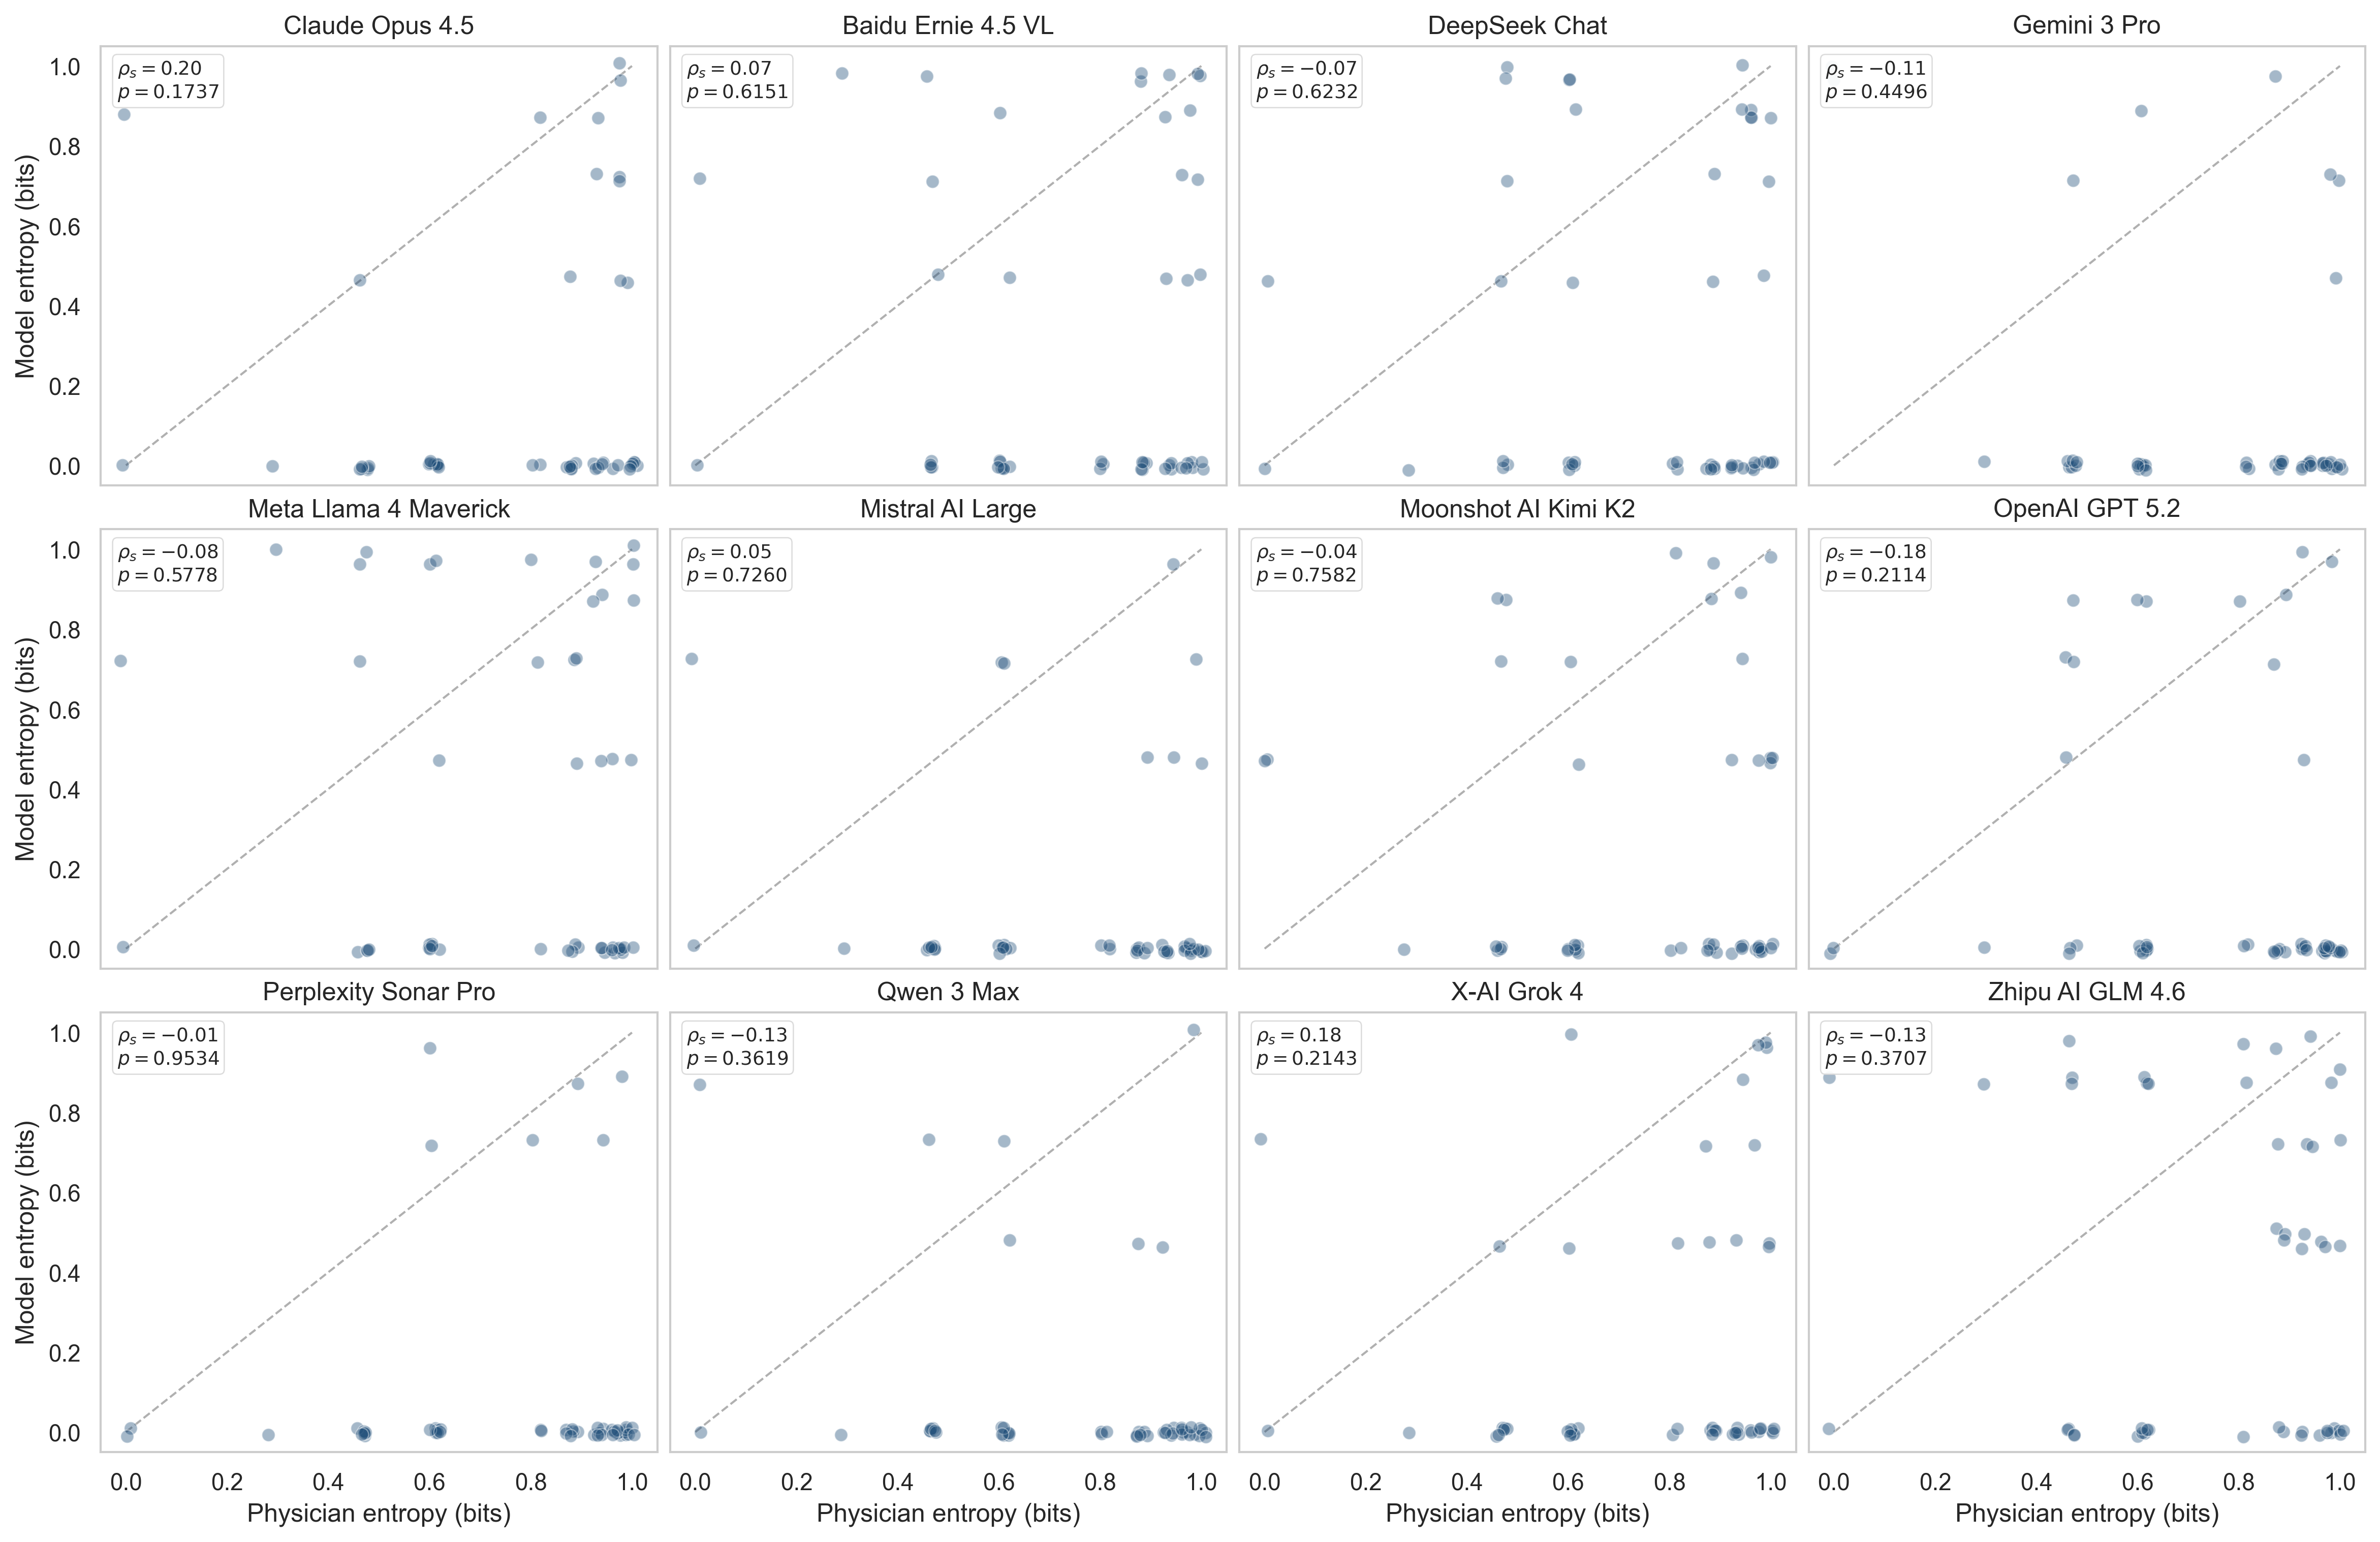

In [23]:
n_models = len(llm_models)
ncols, nrows = 4, 3
rng = np.random.default_rng(42)
# Small jitter separates exact 0/1 stacks without changing the scale.
_jitter = 0.012

_paper_rc = {
    # "font.family": "serif",
    # "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    # "font.size": 10,
    # "axes.labelsize": 11,
    # "axes.titlesize": 10,
    # "xtick.labelsize": 9,
    # "ytick.labelsize": 9,
    # "axes.linewidth": 1.0,
    # "xtick.major.width": 0.9,
    # "ytick.major.width": 0.9,
    # "grid.alpha": 0.45,
    # "grid.linewidth": 0.5,
    "figure.dpi": 300,
    "savefig.bbox": "tight",
}

with plt.rc_context(_paper_rc):
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15.5, 10),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for model, ax in zip(llm_models, axes.flat):
        res = corr_results[model]
        n = len(res.reference_entropies)
        x = res.reference_entropies.astype(float) + rng.uniform(-_jitter, _jitter, size=n)
        y = res.model_entropies.astype(float) + rng.uniform(-_jitter, _jitter, size=n)
        ax.plot([0, 1], [0, 1], ls="--", lw=1.0, color="#b0b0b0", zorder=0)
        ax.scatter(
            x,
            y,
            s=38,
            alpha=0.4,
            color="#1f4e79",
            edgecolors="white",
            linewidths=0.55,
            zorder=2,
            rasterized=True,
        )
        ax.set_title(get_display_name(model))
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.text(
            0.03,
            0.97,
            rf"$\rho_s = {res.spearman_rho:.2f}$" + "\n" + rf"$p = {res.spearman_pvalue:.4f}$",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            zorder=5,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="#d8d8d8",
                linewidth=0.6,
                alpha=0.92,
            ),
        )
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

    for ax in axes[-1, :]:
        ax.set_xlabel("Physician entropy (bits)")
    for ax in axes[:, 0]:
        ax.set_ylabel("Model entropy (bits)")

    for ax in axes.flat[n_models:]:
        ax.set_visible(False)

    # fig.suptitle("Case-level entropy: physician vs. model", fontsize=13)
    

plt.show()

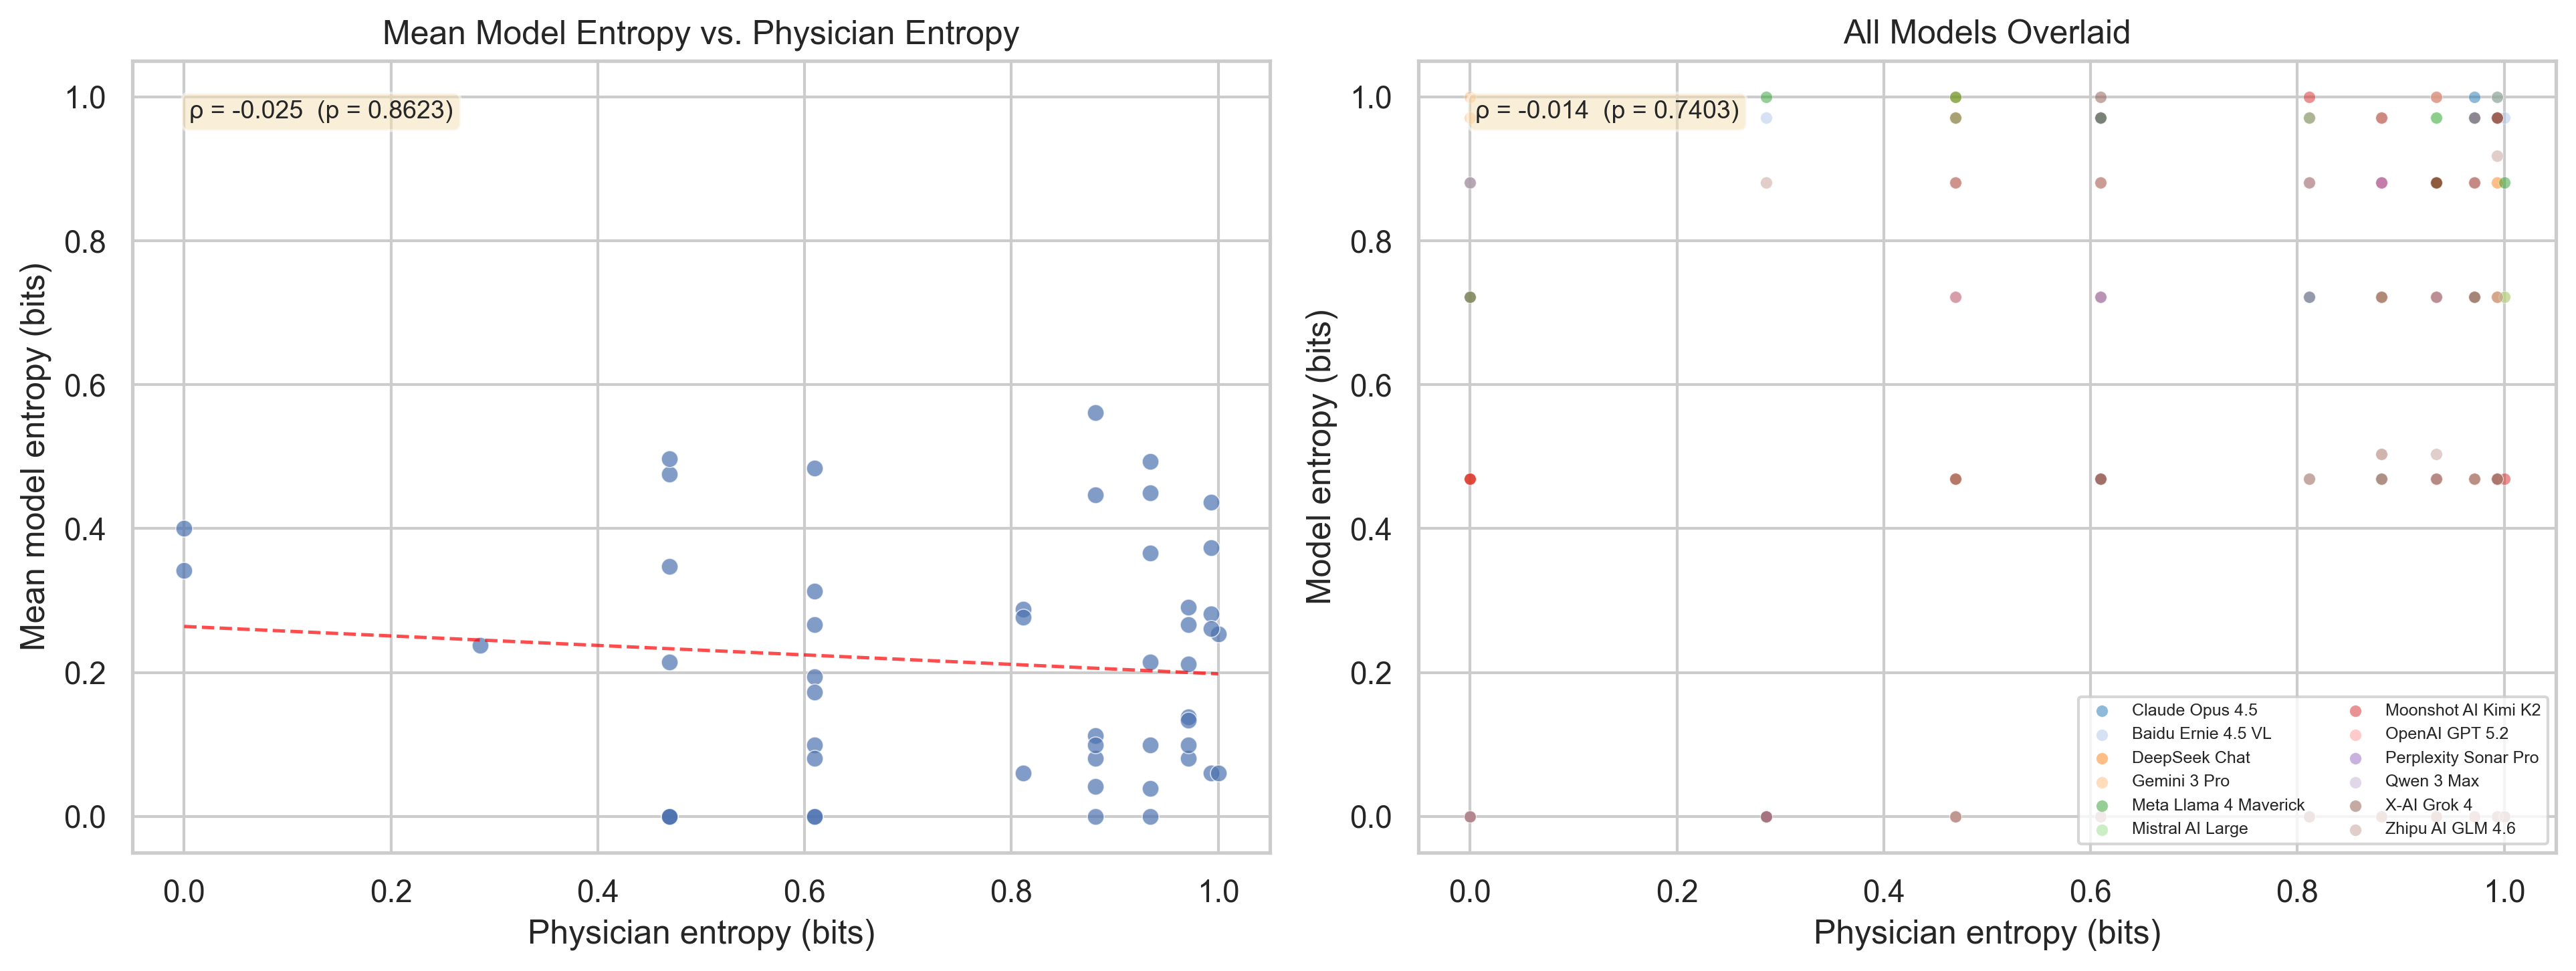

In [21]:
from scipy.stats import spearmanr

common_ids = set(corr_results[llm_models[0]].case_ids)
for model in llm_models[1:]:
    common_ids &= set(corr_results[model].case_ids)
common_ids = sorted(common_ids)

model_entropy_matrix = np.zeros((len(common_ids), len(llm_models)))
for j, model in enumerate(llm_models):
    id_to_ent = dict(zip(corr_results[model].case_ids,
                         corr_results[model].model_entropies))
    for i, cid in enumerate(common_ids):
        model_entropy_matrix[i, j] = id_to_ent[cid]

mean_model_ent = model_entropy_matrix.mean(axis=1)
phys_ent = np.array([physician_entropy[cid] for cid in common_ids])
rho_mean, p_mean = spearmanr(phys_ent, mean_model_ent)

all_phys, all_model = [], []
all_labels = []
for model in llm_models:
    res = corr_results[model]
    all_phys.extend(res.reference_entropies)
    all_model.extend(res.model_entropies)
    all_labels.extend([get_display_name(model)] * len(res.reference_entropies))

all_phys = np.array(all_phys)
all_model = np.array(all_model)
all_labels = np.array(all_labels)
rho_all, p_all = spearmanr(all_phys, all_model)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

ax1.scatter(phys_ent, mean_model_ent, s=36, alpha=0.7,
            edgecolors="white", linewidths=0.4)
z = np.polyfit(phys_ent, mean_model_ent, 1)
x_line = np.linspace(0, 1, 100)
ax1.plot(x_line, np.polyval(z, x_line), ls="--", color="red", lw=1.2, alpha=0.7)
ax1.set_xlabel("Physician entropy (bits)")
ax1.set_ylabel("Mean model entropy (bits)")
ax1.set_title("Mean Model Entropy vs. Physician Entropy")
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.annotate(f"ρ = {rho_mean:.3f}  (p = {p_mean:.4f})",
             xy=(0.05, 0.95), xycoords="axes fraction", fontsize=9,
             verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5))

palette = sns.color_palette("tab20", n_colors=len(llm_models))
model_names = [get_display_name(m) for m in llm_models]
color_map = dict(zip(model_names, palette))

for name in model_names:
    mask = all_labels == name
    ax2.scatter(all_phys[mask], all_model[mask], s=18, alpha=0.5,
                label=name, color=color_map[name],
                edgecolors="white", linewidths=0.2)

ax2.set_xlabel("Physician entropy (bits)")
ax2.set_ylabel("Model entropy (bits)")
ax2.set_title("All Models Overlaid")
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.annotate(f"ρ = {rho_all:.3f}  (p = {p_all:.4f})",
             xy=(0.05, 0.95), xycoords="axes fraction", fontsize=9,
             verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5))
ax2.legend(fontsize=6, loc="lower right", ncol=2, framealpha=0.8)

plt.tight_layout()
plt.show()